# Llama M8b Affinity Score Analysis 
full-dataset normalisation

**Pipeline**

1. Load all 192 cells and subset the 17 characterised for the manuscript
2. QC: zeros and saturated values in the IgG normalisers (A1: IgG2 FITC, A2: IgG total CY5), chip (P1 vs P2) effects
3. Affinity score = antigen score / IgG score (A1: IgG2 FITC, A2: IgG total CY5), per assay and antigen (zero-safe)
4. `log1p` transform
5. z-score per antigen using **full-192** mean and SD (optionally within chip)
6. Percentile rank of each of the 17 within the 192
7. Sensitivity check: pseudocount vs minimum-IgG threshold
8. Figures and export

Normalisation parameters are always estimated on all 192 cells, never on the subset.

## 1. Setup and configuration

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---------------- configuration ----------------
DATA_FILE = "llama_m8bfull.csv"
SEARCH_DIRS = [Path("."), Path("/mnt/user-data/uploads")]

# How to handle zero / near-zero IgG in the denominator
#   "pseudocount": ag / (igg + eps), eps = smallest nonzero normaliser value in that assay (keeps all cells)
#   "threshold"  : ag / igg only where igg >= the quantile below; other cells -> NaN
IGG_METHOD = "pseudocount"
MIN_IGG_QUANTILE = 0.25

TRANSFORM = np.log1p            # applied to the affinity score
NORMALISE_WITHIN_CHIP = False   # True: z-score within P1 and P2 separately (use if chip effect is real)

SUBSET_IDS = [
    "P1-B5", "P1-D6", "P1-F6", "P1-F10", "P1-G11", "P1-H1", "P1-H9", "P1-H11",
    "P2-A12", "P2-B5", "P2-C4", "P2-C12", "P2-D6", "P2-D8", "P2-F6", "P2-G5", "P2-G12",
]

# Assay layout: normaliser column prefix and the antigens measured against it
# (A1 is normalised to IgG2 FITC; A2 is normalised to total IgG CY5)
ASSAYS = {
    "A1": {
        "igg": "A1 IgG2 FITC",
        "antigens": {
            "BtkY72 Cy5": "A1 BtkY72 Cy5",
            "Khosta-2 TRED": "A1 Khosta-2 TRED",
            "SARS-1 DAPI": "A1 SARS-1 DAPI",
            "Yun11 PE": "A1 Yun11 PE",
        },
    },
    "A2": {
        "igg": "A2 IgG total CY5",
        "antigens": {
            "BM4831 PE": "A2 _BM4831 PE",
            "SARS-2 beta TRED": "A2 SARS-2 beta TRED",
            "SARS-2 KP3 DAPI": "A2 SARS-2 KP3 DAPI",
            "IgG2 FITC": "A2 IgG2 FITC",   # IgG2 / total IgG
        },
    },
}   # <-- this closing brace was missing

# Colour by detection channel
CHANNEL_COLOURS = {"Cy5": "#B5639A", "TRED": "#D62828", "DAPI": "#82B6E6",
                   "PE": "#E3C75F", "FITC": "#6AA84F"}
colour_of = lambda name: CHANNEL_COLOURS[name.split()[-1]]

In [36]:
path = next((d / DATA_FILE for d in SEARCH_DIRS if (d / DATA_FILE).exists()), None)
assert path is not None, f"Could not find {DATA_FILE} in {SEARCH_DIRS}"
df = pd.read_csv(path)

df["chip"] = df["ExportID"].str.split("-").str[0]
df["in_subset"] = df["ExportID"].isin(SUBSET_IDS)

missing = sorted(set(SUBSET_IDS) - set(df["ExportID"]))
assert df["ExportID"].is_unique, "Duplicate ExportIDs"
assert not missing, f"Subset IDs not found: {missing}"

print(f"{len(df)} cells | chips: {df['chip'].value_counts().to_dict()} | subset: {df['in_subset'].sum()}")

ANTIGENS = {name: (assay, f"{prefix} : Score")
            for assay, cfg in ASSAYS.items() for name, prefix in cfg["antigens"].items()}
IGG_COL = {assay: f"{cfg['igg']} : Score" for assay, cfg in ASSAYS.items()}

192 cells | chips: {'P1': 96, 'P2': 96} | subset: 17


## 2. QC

The IgG score is the denominator (A1: IgG2 FITC, A2: IgG total CY5), so zeros and saturated values matter most here.

In [37]:
qc = []
for assay, col in IGG_COL.items():
    s = df[col]
    qc.append({
        "assay": assay,
        "n_zero": int((s == 0).sum()),
        "median": s.median(),
        "min_nonzero": s[s > 0].min(),
        "max": s.max(),
        "n_at_max": int((s == s.max()).sum()),
        "subset_n_zero": int((df.loc[df.in_subset, col] == 0).sum()),
    })
display(pd.DataFrame(qc).set_index("assay").round(3))

,n_zero,median,min_nonzero,max,n_at_max,subset_n_zero
assay,,,,,,
A1,12,0.276,0.025,8.211,1,0
A2,1,28.605,8.071,65.769,1,0


Check for chip effects per antigen (Mann-Whitney U, P1 vs P2, Benjamini-Hochberg adjusted). If several antigens
differ between chips, set `NORMALISE_WITHIN_CHIP = True` above.

In [38]:
def bh(p):
    p = np.asarray(p); n = len(p); order = np.argsort(p)
    adj = np.empty(n); prev = 1.0
    for rank, i in zip(range(n, 0, -1), order[::-1]):
        prev = min(prev, p[i] * n / rank); adj[i] = prev
    return adj

rows = []
for name, (assay, col) in ANTIGENS.items():
    a, b = (df.loc[df.chip == c, col] for c in ("P1", "P2"))
    rows.append({"antigen": name, "median_P1": a.median(), "median_P2": b.median(),
                 "p": stats.mannwhitneyu(a, b).pvalue})
chip_tbl = pd.DataFrame(rows).set_index("antigen")
chip_tbl["p_BH"] = bh(chip_tbl["p"].values)
display(chip_tbl.round(4))

,median_P1,median_P2,p,p_BH
antigen,,,,
BtkY72 Cy5,5.7727,3.4479,0.1234,0.2468
Khosta-2 TRED,7.2668,7.1761,0.9969,0.9969
SARS-1 DAPI,5.8581,7.1368,0.0705,0.1881
Yun11 PE,9.8679,11.2970,0.5169,0.5908
BM4831 PE,4.5292,4.8807,0.1789,0.2862
SARS-2 beta TRED,24.8422,29.5463,0.0024,0.0097
SARS-2 KP3 DAPI,5.3077,5.8308,0.4497,0.5908
IgG2 FITC,1.7654,0.1311,0.0000,0.0000


## 3. Affinity score

`affinity = antigen score / IgG score`, computed per assay and antigen. The normaliser is assay-specific: A1 uses IgG2 FITC, A2 uses total IgG (CY5). Both zero-handling methods are
computed; `IGG_METHOD` selects which one flows through the rest of the notebook.

The pseudocount is the smallest non-zero normaliser value in each assay, so it differs by assay (A1 IgG2 FITC: about 0.025; A2 IgG total CY5: about 8.07).

In [39]:
def affinity(df, method):
    out = pd.DataFrame(index=df.index)
    for name, (assay, col) in ANTIGENS.items():
        ag, igg = df[col], df[IGG_COL[assay]]
        if method == "pseudocount":
            eps = igg[igg > 0].min()
            out[name] = ag / (igg + eps)
        elif method == "threshold":
            thr = igg.quantile(MIN_IGG_QUANTILE)
            keep = igg >= thr
            out[name] = ag.where(keep) / igg.where(keep)
        else:
            raise ValueError(method)
    return out

aff = affinity(df, IGG_METHOD)
print(f"method = {IGG_METHOD} | NaN affinity scores: {int(aff.isna().sum().sum())}")
aff.describe().T[["count", "min", "50%", "max"]].round(2)

method = pseudocount | NaN affinity scores: 0


,count,min,50%,max
BtkY72 Cy5,192.0,0.0,10.23,582.16
Khosta-2 TRED,192.0,0.0,12.39,626.20
SARS-1 DAPI,192.0,0.0,13.19,462.03
Yun11 PE,192.0,0.0,16.68,1200.77
BM4831 PE,192.0,0.0,0.12,1.15
SARS-2 beta TRED,192.0,0.0,0.72,1.42
SARS-2 KP3 DAPI,192.0,0.0,0.15,0.94
IgG2 FITC,192.0,0.0,0.01,2.91


## 4-5. Transform and calculate the z-score using all exports to define the parameters

In [40]:
def zscore(x, groups=None):
    # mean/SD from every cell present (the full dataset), NaN-safe; optionally within chip
    if groups is None:
        return (x - x.mean()) / x.std(ddof=1)
    return x.groupby(groups).transform(lambda s: (s - s.mean()) / s.std(ddof=1))

def pipeline(df, method):
    a = affinity(df, method)
    t = a.apply(TRANSFORM)
    z = t.apply(lambda s: zscore(s, df["chip"] if NORMALISE_WITHIN_CHIP else None))
    pct = z.rank(pct=True) * 100   # percentile within the full dataset
    return a, t, z, pct

aff, logaff, z, pct = pipeline(df, IGG_METHOD)
z.describe().T[["count", "mean", "std", "min", "max"]].round(2)

,count,mean,std,min,max
BtkY72 Cy5,192.0,0.0,1.0,-1.69,2.52
Khosta-2 TRED,192.0,-0.0,1.0,-1.73,2.18
SARS-1 DAPI,192.0,-0.0,1.0,-1.58,2.00
Yun11 PE,192.0,0.0,1.0,-1.64,2.16
BM4831 PE,192.0,-0.0,1.0,-1.28,4.64
SARS-2 beta TRED,192.0,0.0,1.0,-3.51,2.34
SARS-2 KP3 DAPI,192.0,0.0,1.0,-1.21,3.96
IgG2 FITC,192.0,-0.0,1.0,-0.35,13.08


## 6. Manuscript subset in context of full export

In [41]:
sub = df["in_subset"]
pct_sub = pct[sub].set_index(df.loc[sub, "ExportID"])
z_sub = z[sub].set_index(df.loc[sub, "ExportID"])

print("Percentile rank within all 192 exports (higher # = higher affinity score)")
display(pct_sub.round(0).astype("Int64"))
print("Median percentile of the subset, per antigen:")
display(pct_sub.median().round(1).to_frame("median_percentile").T)

Percentile rank within all 192 exports (higher # = higher affinity score)


,BtkY72 Cy5,Khosta-2 TRED,SARS-1 DAPI,Yun11 PE,BM4831 PE,SARS-2 beta TRED,SARS-2 KP3 DAPI,IgG2 FITC
ExportID,,,,,,,,
P1-B5,85,93,5,92,93,72,84,42
P1-D6,14,17,35,14,17,73,28,99
P1-F6,39,43,15,47,82,54,73,92
P1-F10,76,52,54,50,73,69,17,28
P1-G11,60,43,81,15,68,96,10,49
P1-H1,45,35,14,35,68,23,94,66
P1-H9,31,21,20,23,66,59,45,77
P1-H11,8,11,28,17,9,14,17,74
P2-A12,4,14,19,18,48,89,5,66


Median percentile of the subset, per antigen:


,BtkY72 Cy5,Khosta-2 TRED,SARS-1 DAPI,Yun11 PE,BM4831 PE,SARS-2 beta TRED,SARS-2 KP3 DAPI,IgG2 FITC
median_percentile,56.8,47.9,34.9,46.9,68.2,63.5,46.9,52.6


## 7. Sensitivity: 
This compares the pseudocount to using the zero values. 
Percentile ranks of the 17 under both methods. 
A high Spearman correlation means the choice does not matter much for the subset.

In [42]:
_, _, _, pct_pc = pipeline(df, "pseudocount")
_, _, _, pct_th = pipeline(df, "threshold")

rows = []
for name in ANTIGENS:
    a, b = pct_pc.loc[sub, name], pct_th.loc[sub, name]
    ok = a.notna() & b.notna()
    rows.append({"antigen": name,
                 "n_subset_kept_by_threshold": int(b.notna().sum()),
                 "spearman_pseudocount_vs_threshold": stats.spearmanr(a[ok], b[ok])[0] if ok.sum() > 2 else np.nan,
                 "median_pct_pseudocount": a.median(),
                 "median_pct_threshold": b.median()})
display(pd.DataFrame(rows).set_index("antigen").round(2))

,n_subset_kept_by_threshold,spearman_pseudocount_vs_threshold,median_pct_pseudocount,median_pct_threshold
antigen,,,,
BtkY72 Cy5,14,1.00,56.77,53.82
Khosta-2 TRED,14,1.00,47.92,55.21
SARS-1 DAPI,14,1.00,34.90,38.89
Yun11 PE,14,1.00,46.88,51.74
BM4831 PE,12,0.99,68.23,70.14
SARS-2 beta TRED,12,0.97,63.54,65.97
SARS-2 KP3 DAPI,12,1.00,46.88,39.24
IgG2 FITC,12,0.99,52.60,62.15


## 8. Figures

**Distributions.** All 192 cells are shown in the lighter bars, the 17 characterised cells in the darker bars (same bins).

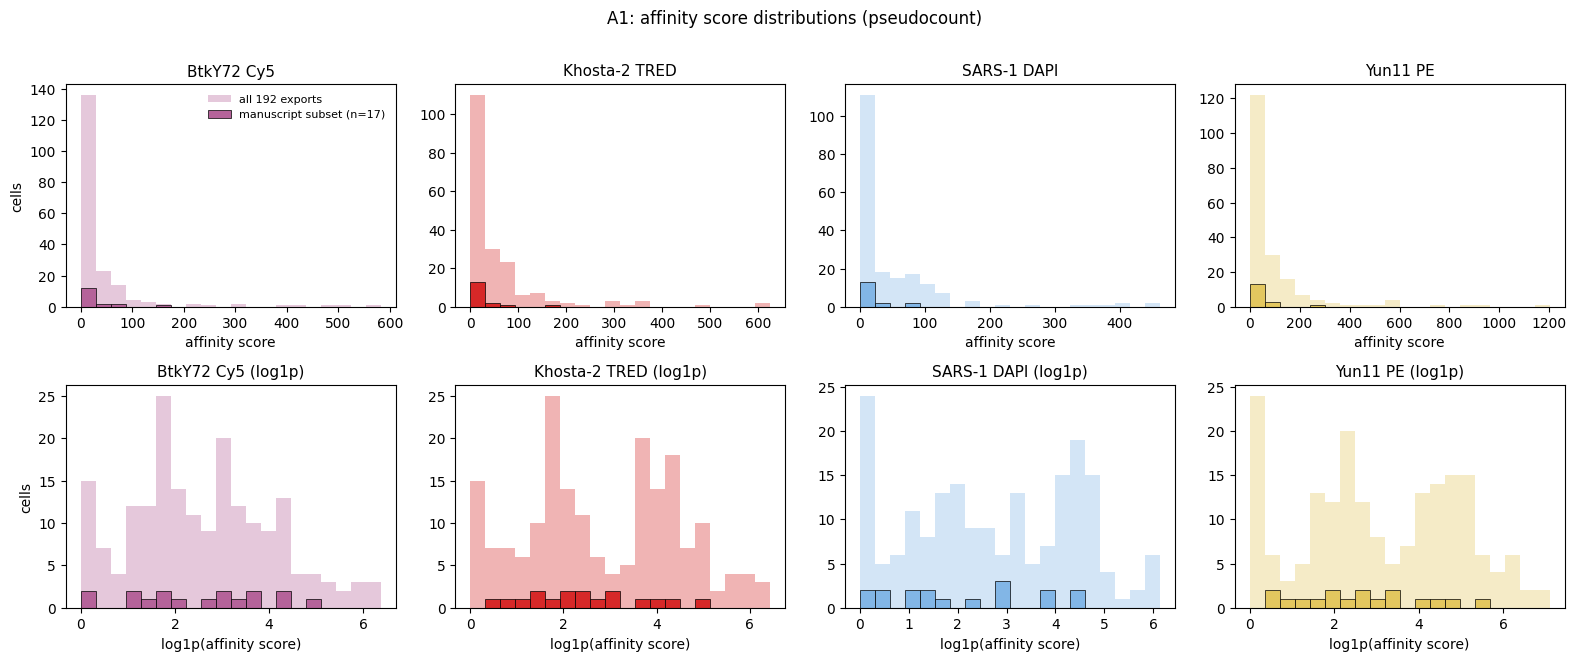

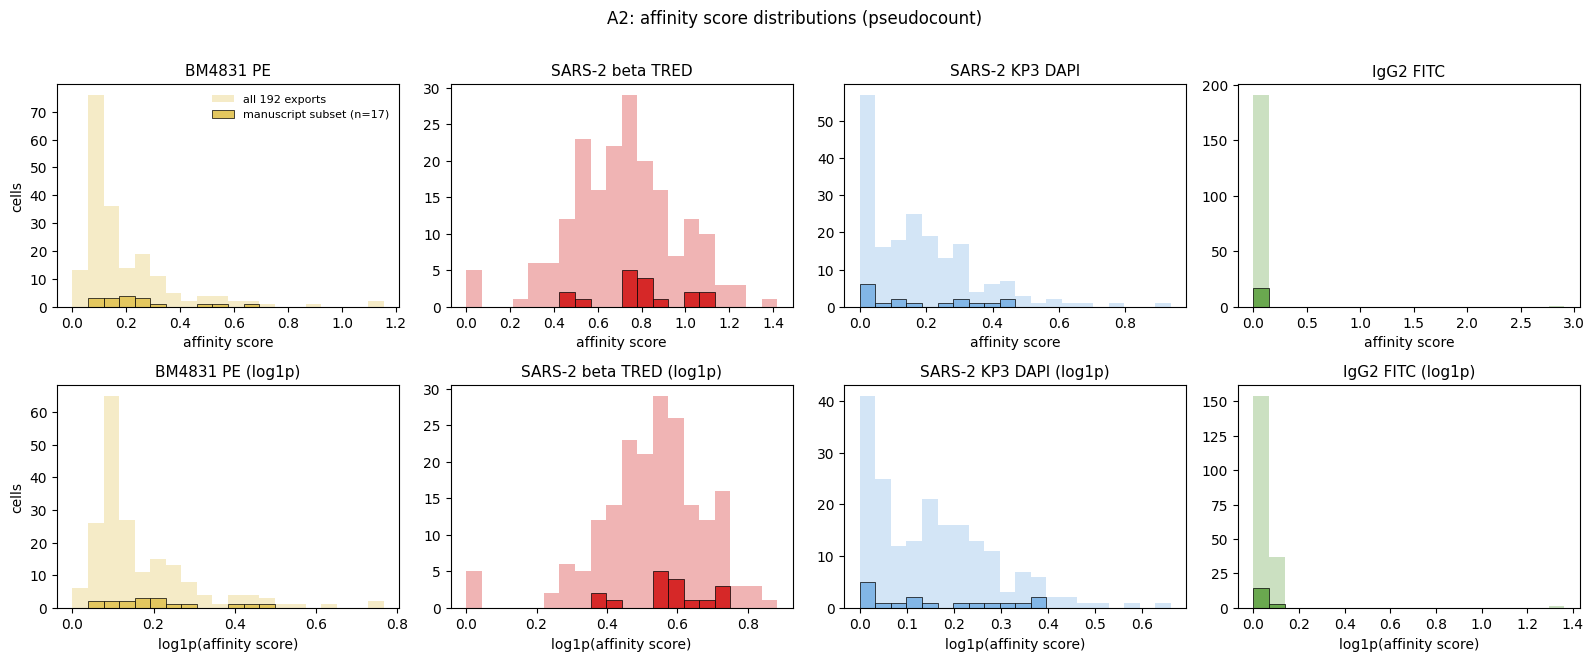

In [43]:
def plot_distributions(assay):
    names = [n for n, (a, _) in ANTIGENS.items() if a == assay]
    fig, axes = plt.subplots(2, len(names), figsize=(4 * len(names), 6.5), squeeze=False)
    for j, name in enumerate(names):
        for i, (vals, lab) in enumerate([(aff[name], "affinity score"),
                                         (logaff[name], "log1p(affinity score)")]):
            ax = axes[i, j]
            v = vals.dropna()
            bins = np.histogram_bin_edges(v, bins=20)
            ax.hist(v, bins=bins, color=colour_of(name), alpha=0.35, edgecolor="none", label="all 192 exports")
            ax.hist(vals[sub].dropna(), bins=bins, color=colour_of(name),
                    edgecolor="black", linewidth=0.5, label="manuscript subset (n=17)")
            ax.set_title(f"{name}" + ("" if i == 0 else " (log1p)"), fontsize=11)
            ax.set_xlabel(lab); ax.set_ylabel("cells" if j == 0 else "")
            if i == 0 and j == 0:
                ax.legend(frameon=False, fontsize=8)
    fig.suptitle(f"{assay}: affinity score distributions ({IGG_METHOD})", y=1.01)
    fig.tight_layout()
    return fig

for assay in ASSAYS:
    plot_distributions(assay)
    plt.show()

**Subset in context.** Each column is one antigen: grey = all 192 cells (z-scored on the full dataset), coloured = the 17 characterised cells.

Using font: Avenir


/var/folders/gw/tqtm2b315yd232c9f43vnpyr0000gn/T/ipykernel_62032/4013394083.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


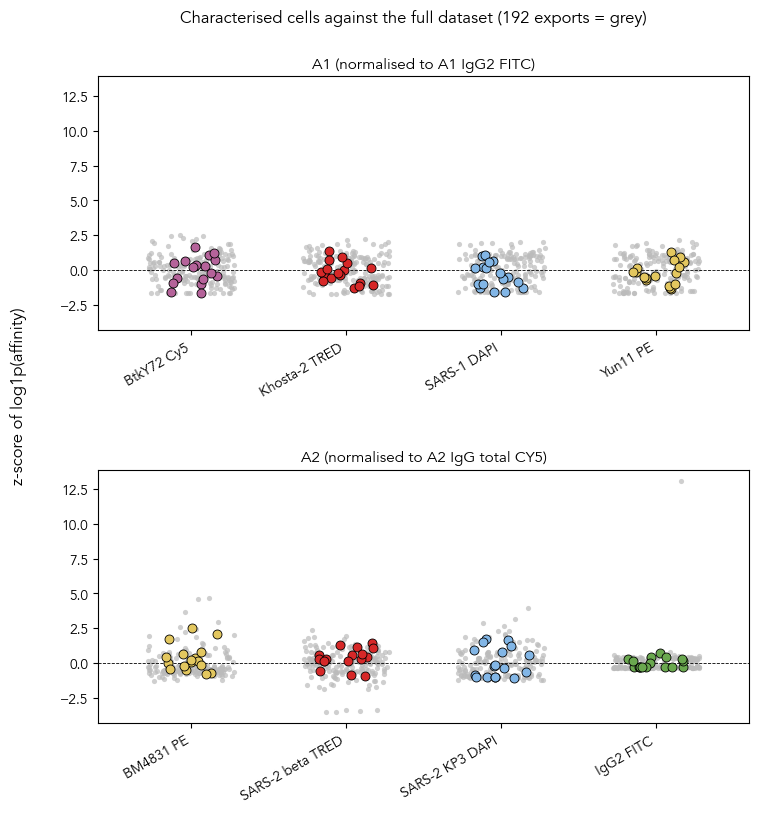

In [44]:
from matplotlib import font_manager

SHOW_CHIP = False   # True: circles = P1, squares = P2 for the characterised cells

# Avenir ships with macOS, not with matplotlib; fall back gracefully if it is not installed
FONT_PREF = ["Avenir", "Avenir Next", "Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
installed = {f.name for f in font_manager.fontManager.ttflist}
print("Using font:", next((f for f in FONT_PREF if f in installed), "matplotlib default"))

with plt.rc_context({"font.family": "sans-serif", "font.sans-serif": FONT_PREF}):
    fig, axes = plt.subplots(
        len(ASSAYS), 1, sharey=True,
        figsize=(1.6 * max(len(c["antigens"]) for c in ASSAYS.values()) + 2, 4.2 * len(ASSAYS)),
        gridspec_kw={"hspace": 0.55},
    )
    rng = np.random.default_rng(0)

    for ax, (assay, cfg) in zip(axes, ASSAYS.items()):
        names = list(cfg["antigens"])
        for k, name in enumerate(names):
            bg = z.loc[~sub, name].dropna()
            ax.scatter(k + rng.uniform(-0.28, 0.28, len(bg)), bg,
                       s=14, color="#BBBBBB", alpha=0.7, linewidths=0)

            for chip, marker in (("P1", "o"), ("P2", "s" if SHOW_CHIP else "o")):
                fg = z.loc[sub & (df["chip"] == chip), name].dropna()
                ax.scatter(k + rng.uniform(-0.18, 0.18, len(fg)), fg, s=42, marker=marker,
                           color=colour_of(name), edgecolor="black", linewidth=0.6, zorder=3)

        ax.axhline(0, color="black", lw=0.6, ls="--")
        ax.set_xlim(-0.6, len(names) - 0.4)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=30, ha="right")
        ax.set_title(f"{assay} (normalised to {cfg['igg']})", fontsize=11)

    fig.supylabel("z-score of log1p(affinity)")
    fig.suptitle("Characterised cells against the full dataset (192 exports = grey)", y=0.96)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

    fig.savefig("LlamaM8b Affinity Scores Scatter.svg", bbox_inches="tight")            # vector, editable

### Notes for the methods section

- z-score and percentile parameters come from all 192 cells, not the 17 characterised cells.
- Uncharacterised cells are unknown, not negative: treat the rest of the dataset as background, not as a control group.
- A1 affinity is per IgG2 FITC and A2 affinity is per total IgG (CY5), so the two assays measure different quantities: compare cells within an assay (z-scores/percentiles), not raw affinity values across assays.
- Report the zero-handling method (`IGG_METHOD`) and the chip handling (`NORMALISE_WITHIN_CHIP`).

/var/folders/gw/tqtm2b315yd232c9f43vnpyr0000gn/T/ipykernel_62032/3153178417.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


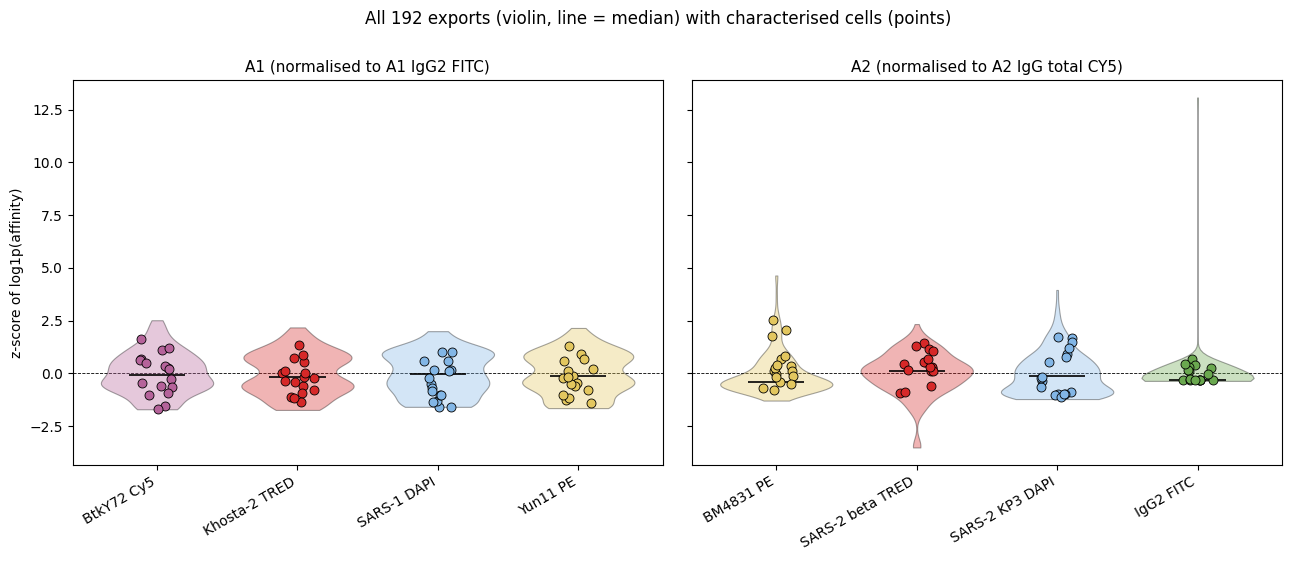

In [45]:
SHOW_POINTS = True     # overlay the 17 characterised cells
YLIM = None            # e.g. (-4, 5) to cap the axis if one outlier stretches a panel

fig, axes = plt.subplots(
    1, len(ASSAYS), figsize=(1.7 * len(ANTIGENS) + 2, 5), sharey=True,
    gridspec_kw={"width_ratios": [len(cfg["antigens"]) for cfg in ASSAYS.values()],
                 "wspace": 0.05},
)
rng = np.random.default_rng(0)

for ax, (assay, cfg) in zip(axes, ASSAYS.items()):
    names = list(cfg["antigens"])
    for k, name in enumerate(names):
        allv = z[name].dropna().values            # all 192 cells (full-dataset distribution)
        parts = ax.violinplot(allv, positions=[k], widths=0.8, showextrema=False,
                              showmedians=True)
        body = parts["bodies"][0]
        body.set_facecolor(colour_of(name)); body.set_edgecolor("black")
        body.set_alpha(0.35); body.set_linewidth(0.8)
        parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.2)

        if SHOW_POINTS:
            fg = z.loc[sub, name].dropna()
            ax.scatter(k + rng.uniform(-0.12, 0.12, len(fg)), fg, s=42,
                       color=colour_of(name), edgecolor="black", linewidth=0.6, zorder=3)

    ax.axhline(0, color="black", lw=0.6, ls="--", zorder=0)
    ax.set_xlim(-0.6, len(names) - 0.4)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_title(f"{assay} (normalised to {cfg['igg']})", fontsize=11)

if YLIM:
    axes[0].set_ylim(*YLIM)
axes[0].set_ylabel("z-score of log1p(affinity)")
fig.suptitle("All 192 exports (violin, line = median) with characterised cells (points)", y=1.02)
fig.tight_layout()
plt.show()